In [61]:
#Numpy is used for data manipulation and setting up the environent for the models
import numpy as np
import pandas as pd
print("Numpy version:", np.__version__)

#Adjustable values for data testing
#----------------------------------
DATA = 5000
NEURALS = 64
#-----------------------------------

#This is initialization of simple dataset
X_train = np.random.rand(DATA, 1)
y_train = (X_train > 0.7).astype(int)

print(f"Dataset creatded with {len(X_train)} DATA.")


X = np.linspace(0,10, DATA).reshape(-1,1)

#Linear Regression Data Environment
#simple y = mx +b
y_linear = 2 * X + np.random.normal(0, 1, (DATA,1))

#Curved Regression Data Environment
# now using y = ax^2 +sin(x) + noise, adding complexity
y_curved = 0.5 * X**2 + np.sin(X) + np.random.normal(0, 2, (DATA,1))
stage_a = X * 1.5
stage_b = np.sin(stage_a)
#Other option: stage_b = np.cos(stage_a)*stage_a

#Chained Regression Data Environment ran through specific vars
#chain of transformationst that has noise at each stage
y_chain = stage_b + np.random.normal(0, 0.5, (DATA,1))


model_par_results = {}
results_data = {
    "Model": ["Sequential", "Parallel", "Modular"],
    "Linear_Loss": [(0,0), (0,0), (0,0)],
    "Curved_Loss": [(0,0), (0,0), (0,0)],
    "Chain_Loss":  [(0,0), (0,0), (0,0)],
}

environments = {
    "Linear": y_linear,
    "Curved": y_curved,
    "Chain": y_chain
}
df_results = pd.DataFrame(results_data).set_index("Model")

print("Linear, Curved, and Chained regression datasets ready")


Numpy version: 2.0.2
Dataset creatded with 5000 DATA.
Linear, Curved, and Chained regression datasets ready


In [62]:
import tensorflow as tf
from tensorflow.keras import layers
import time

#Model 1: Sequential Order
model_seq = tf.keras.Sequential([
    layers.Dense(NEURALS, activation='relu',input_shape=(1,)),
    layers.Dense(NEURALS, activation='relu'),
    layers.Dense(1)

])

model_seq.compile(optimizer='adam', loss='mse')

# Training and timing the process

for name, scenario in environments.items():
    start_train = time.time()
    train_time = time.time() - start_train
    history = model_seq.fit(X, scenario, epochs=50, verbose=0)
    loss_history = history.history['loss'][-1]

    df_results.at["Sequential", f"{name}_Loss"] = (loss_history, train_time)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:


import tensorflow as tf
from tensorflow.keras import layers
import time
#Model 2: Parallel Structuring
#Adjustable variables
#-------------------------------------
NEURALS = NEURALS
#-------------------------------------

inputs = layers.Input(shape=(1,))

branch_a = layers.Dense(NEURALS, activation='relu')(inputs)

branch_b = layers.Dense(NEURALS, activation='sigmoid')(inputs)

merged = layers.concatenate([branch_a, branch_b])

outputs = layers.Dense(1)(merged)

modelparallel = tf.keras.Model(inputs=inputs, outputs=outputs)

modelparallel.compile(optimizer='adam', loss='mse')

# Training and timing the process

for name, scenario in environments.items():

    start_train = time.time()
    train_time = time.time() - start_train
    history = model_seq.fit(X, scenario, epochs=50, verbose=0)
    loss_history = history.history['loss'][-1]

    df_results.at["Parallel", f"{name}_Loss"] = (loss_history, train_time)


In [64]:
import torch


class Modularnet(torch.nn.Module):
    def __init__(self, NEURAL_VALUE):

        super(Modularnet, self).__init__()
        self.b1 = torch.nn.Linear(1,NEURAL_VALUE)
        self.b2 = torch.nn.Linear(NEURAL_VALUE,1)

    def forward(self,x):

        #start first prcessing layer
        x = self.b1(x)

        #testing layer b1
        x = torch.relu(x)

        #testing layer b2
        x = self.b2(x)

        return x

for name, scenario in environments.items():
    target_sensor = torch.from_numpy(scenario.astype(np.float32))
    inputs_t = torch.from_numpy(X_train).float()

    modular_network = Modularnet(NEURALS)
    optimizer = torch.optim.Adam(modular_network.parameters(), lr=0.01)
    criterion = torch.nn.MSELoss()

    for epoch in range(100):
        modular_network.train()

        """ArithmeticError

        inputs_t = torch.from_numpy(X_train).float()
        targets_t = torch.from_numpy(scenario).float()
        """
        outputs = modular_network(inputs_t)
        loss = criterion(outputs, target_sensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    final_loss = loss.item()
    df_results.at["Modular", f"{name}_Loss"] = (final_loss, train_time)
    


Text(0.5, 1.0, 'Chained Regression Data')

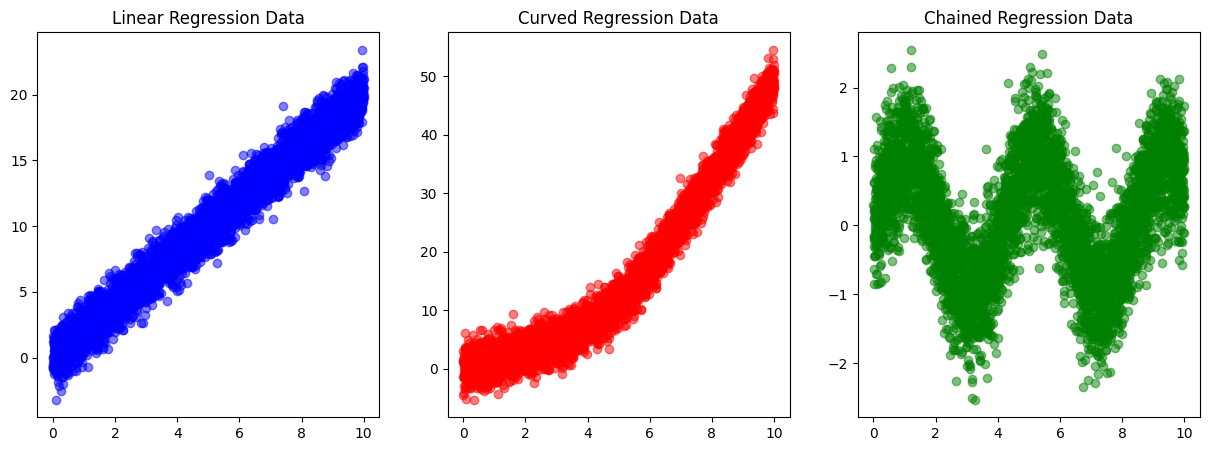

In [ ]:
#Control Group : Visualizing the datasets
from matplotlib import pyplot as plt

plt.figure(figsize=(15,5))

#Blue corresponds to the linear regression data
plt.subplot(1,3,1)
plt.scatter(X, y_linear, color='blue', alpha=0.5)
plt.title("Linear Regression Data")

#Red corresponds to the curved regression data
plt.subplot(1,3,2)
plt.scatter(X, y_curved, color='red', alpha=0.5)
plt.title("Curved Regression Data")

#Green corresponds to the chained regression data
plt.subplot(1,3,3)
plt.scatter(X, y_chain, color='green', alpha=0.5)
plt.title("Chained Regression Data")

ValueError: x and y must be the same size

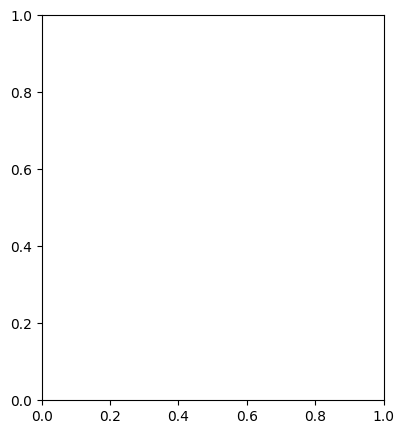

In [ ]:
"""


#Control Group : Visualizing the datasets
from matplotlib import pyplot as plt

plt.figure(figsize=(15,5))

#Blue corresponds to the linear regression data
plt.subplot(1,3,1)
plt.scatter(df_results.index.get_loc("Sequential"), df_results.loc["Sequential", "Linear_Loss"], color='blue', alpha=0.5)
plt.scatter(df_results.index.get_loc("Parallel"), df_results.loc["Parallel", "Linear_Loss"], color='orange', alpha=0.5)
plt.scatter(df_results.index.get_loc("Modular"), df_results.loc["Modular", "Linear_Loss"], color='green', alpha=0.5)

plt.title("Linear Regression Data")

#Red corresponds to the curved regression data
plt.subplot(1,3,2)
plt.scatter(X, y_curved, color='red', alpha=0.5)
plt.title("Curved Regression Data")

#Green corresponds to the chained regression data
plt.subplot(1,3,3)
plt.scatter(X, y_chain, color='green', alpha=0.5)
plt.title("Chained Regression Data")
"""

In [66]:
display(df_results)
# Through a tuple dictionary, we can see both the loss and training time for each model and scenario



,Linear_Loss,Curved_Loss,Chain_Loss
Model,,,
Sequential,"(1.0288053750991821, 7.152557373046875e-07)","(3.9635839462280273, 9.5367431640625e-07)","(0.2791255712509155, 7.152557373046875e-07)"
Parallel,"(1.0436087846755981, 1.1920928955078125e-06)","(3.9379680156707764, 7.152557373046875e-07)","(0.2748701274394989, 1.1920928955078125e-06)"
Modular,"(34.46988296508789, 1.1920928955078125e-06)","(228.1029052734375, 1.1920928955078125e-06)","(0.7476001977920532, 1.1920928955078125e-06)"
